#  LangChain Course — Phase 1: Prompt Engineering Playground

---

   
> **Tools:** Python · HuggingFace Transformers · Jupyter Notebook  
> **No API Key Required** — All models run locally via HuggingFace Hub

---

##  What This Notebook Does

| Section | What is Built |
|---|---|
| **1. Setup** | Install libraries, detect GPU/CPU, define utilities |
| **2. Multi-Model Loading** | Load 3 different HuggingFace models (Flan-T5, GPT-2, DistilGPT2) |
| **3. Tokenization Lab** | Compare how 3 tokenizers (BPE, WordPiece, SentencePiece) process the same text |
| **4. Embeddings & Similarity** | Visualize semantic similarity with GPT-2 embeddings |
| **5. PromptTemplate Engine** | Build a reusable LangChain-style PromptTemplate class |
| **6. Zero-Shot Playground** | Run & compare zero-shot prompts across multiple tasks |
| **7. Few-Shot Playground** | Build few-shot prompts; measure quality improvement |
| **8. Chain-of-Thought Lab** | CoT vs standard prompts on reasoning tasks |
| **9. Multi-Model Comparison** | Same prompt → 3 models → compare outputs + metrics |
| **10. Chatbot WITHOUT Memory** | Stateless chatbot (shows the problem) |
| **11. Chatbot WITH Memory** | Context-window memory chatbot (solves the problem) |
| **12. Final Dashboard** | Visual summary of all results |

---

## 1. Environment Setup

In [1]:
!pip install --upgrade -q \
    "transformers>=4.41.0,<4.46.0" \
    "torchvision>=0.18.0" \
    "accelerate>=0.26.0" \
    "sentencepiece" \
    "datasets"

print("Patched successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.

---
## 2. Multi-Model Loading

We load **3 different architecture types** to compare their outputs throughout this notebook:

| Model | Architecture | Params | Best For |
|---|---|---|---|
| `google/flan-t5-base` | Encoder-Decoder | 250M | Instructions, Q&A, summarization |
| `gpt2` | Decoder-Only | 124M | Text generation, completion |
| `distilgpt2` | Decoder-Only (distilled) | 82M | Fast inference, demos |

In [2]:
#Core Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown
import time
import textwrap
import re
from copy import deepcopy

from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    AutoModelForSeq2SeqLM, pipeline,
    GPT2Tokenizer, GPT2Model,
)
import torch

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f" Ready!  PyTorch {torch.__version__}  |  Device: {DEVICE.upper()}")

#Shared Pretty-Print Utility
def print_result(label, prompt, response, time_s=None, width=72):
    """Nicely formatted prompt/response box."""
    sep = "═" * width
    thin = "─" * width
    print(f"\n{sep}")
    print(f"  {label}")
    print(thin)
    print("  PROMPT:")
    for line in textwrap.wrap(prompt.strip(), width - 5):
        print(f"     {line}")
    print(thin)
    print("  RESPONSE:")
    for line in textwrap.wrap(str(response).strip(), width - 5):
        print(f"     {line}")
    if time_s:
        print(f"   {time_s:.2f}s  |  {len(str(response))} chars")
    print(sep)
    return response

print("Utilities defined!")

 Ready!  PyTorch 2.12.0+cu130  |  Device: CUDA
Utilities defined!


In [3]:
# loaded Flan-T5 directly via model+tokenizer and wrap it to match the
# same pipe(prompt)[0]['generated_text'] interface used everywhere below.

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    pipeline, T5ForConditionalGeneration, T5Tokenizer,
)
import torch

print(" Loading models (first run downloads from HuggingFace Hub)...\n")

# Model 1: Flan-T5-Base (Encoder-Decoder, instruction-tuned)
print("  [1/3] Loading google/flan-t5-base ...")
t0 = time.time()
_flan_tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
_flan_model     = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")
_flan_model.eval()

def flan_pipe(prompt, max_new_tokens=200, **kwargs):
    """Callable wrapper for Flan-T5 — returns [{"generated_text": str}]."""
    if isinstance(prompt, str):
        prompt = [prompt]
    results = []
    for p in prompt:
        inputs = _flan_tokenizer(p, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            output_ids = _flan_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
            )
        text = _flan_tokenizer.decode(output_ids[0], skip_special_tokens=True)
        results.append({"generated_text": text})
    return results

print(f"        flan-t5-base loaded in {time.time()-t0:.1f}s")

# Model 2: GPT-2 (Decoder-Only, base — NOT instruction-tuned)
print("  [2/3] Loading gpt2 ...")
t0 = time.time()
gpt2_pipe = pipeline(
    "text-generation", model="gpt2",device=0,
    max_new_tokens=150, do_sample=True,
    temperature=0.7, pad_token_id=50256,
)
print(f"        gpt2 loaded in {time.time()-t0:.1f}s")

# Model 3: DistilGPT2 (smaller, faster GPT-2 variant)
print("  [3/3] Loading distilgpt2 ...")
t0 = time.time()
dgpt2_pipe = pipeline(
    "text-generation", model="distilgpt2",device=0,
    max_new_tokens=150, do_sample=True,
    temperature=0.7, pad_token_id=50256,
)
print(f"        distilgpt2 loaded in {time.time()-t0:.1f}s")

#  Convenience dict for multi-model loops
MODELS = {
    "Flan-T5 (250M, Enc-Dec)": flan_pipe,
    "GPT-2 (124M, Dec-Only)": gpt2_pipe,
    "DistilGPT2 (82M, Dec-Only)": dgpt2_pipe,
}

print("\n All 3 models ready! (flan_pipe, gpt2_pipe, dgpt2_pipe, MODELS)")

 Loading models (first run downloads from HuggingFace Hub)...

  [1/3] Loading google/flan-t5-base ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

        distilgpt2 loaded in 3.7s

 All 3 models ready! (flan_pipe, gpt2_pipe, dgpt2_pipe, MODELS)


In [4]:
# Quick Sanity Check: Same Prompt  All 3 Models
sanity_prompt = "Translate English to French: I love learning AI."
print(f"\n Sanity Check Prompt: '{sanity_prompt}'\n")

for model_name, pipe in MODELS.items():
    t0 = time.time()
    out = pipe(sanity_prompt)[0]['generated_text']
    elapsed = time.time() - t0
    print(f"   {model_name}")
    print(f"     {out[:200]}")
    print(f"       {elapsed:.2f}s\n")



 Sanity Check Prompt: 'Translate English to French: I love learning AI.'

   Flan-T5 (250M, Enc-Dec)
     J'aime l'apprentissage d'AI.
       2.01s

   GPT-2 (124M, Dec-Only)
     Translate English to French: I love learning AI. The only reason I can't speak Spanish is because I'm not fluent in English. I want to be able to communicate with people that are interested in AI.

Us
       3.03s

   DistilGPT2 (82M, Dec-Only)
     Translate English to French: I love learning AI. There's an absolute amount of information that I can tell. I'm learning the basics from the source code.

So, I want to begin by saying that I'm not go
       0.89s



---
## 3. Tokenization Lab



In [6]:
# Load Tokenizers
from transformers import AutoTokenizer

TOKENIZERS = {
    "GPT-2 (BPE)":          AutoTokenizer.from_pretrained("gpt2"),
    "BERT (WordPiece)":      AutoTokenizer.from_pretrained("bert-base-uncased"),
    "Flan-T5 (SentencePiece)": AutoTokenizer.from_pretrained("google/flan-t5-base"),
}

test_sentences = [
    "LangChain is a framework for building LLM applications.",
    "Tokenization splits text into subwords like 'un' + 'believ' + 'able'.",
    "AI is transforming every industry — from healthcare to finance!",
    "数据科学很有趣!",   # Chinese — shows how non-English gets tokenized
]

print("═"*72)
print("            TOKENIZATION COMPARISON — 3 Tokenizer Families")
print("═"*72)

for sentence in test_sentences:
    print(f"\n Text: {sentence}")
    for name, tok in TOKENIZERS.items():
        tokens = tok.tokenize(sentence)
        ids    = tok.encode(sentence, add_special_tokens=False)
        print(f"   [{name:30s}]  {len(tokens):2d} tokens  vocab={tok.vocab_size:,}")
        print(f"      Tokens: {tokens}")

════════════════════════════════════════════════════════════════════════
            TOKENIZATION COMPARISON — 3 Tokenizer Families
════════════════════════════════════════════════════════════════════════

 Text: LangChain is a framework for building LLM applications.
   [GPT-2 (BPE)                   ]  12 tokens  vocab=50,257
      Tokens: ['L', 'ang', 'Chain', 'Ġis', 'Ġa', 'Ġframework', 'Ġfor', 'Ġbuilding', 'ĠLL', 'M', 'Ġapplications', '.']
   [BERT (WordPiece)              ]  12 tokens  vocab=30,522
      Tokens: ['lang', '##chai', '##n', 'is', 'a', 'framework', 'for', 'building', 'll', '##m', 'applications', '.']
   [Flan-T5 (SentencePiece)       ]  14 tokens  vocab=32,100
      Tokens: ['▁Lang', 'Ch', 'a', 'in', '▁is', '▁', 'a', '▁framework', '▁for', '▁building', '▁L', 'LM', '▁applications', '.']

 Text: Tokenization splits text into subwords like 'un' + 'believ' + 'able'.
   [GPT-2 (BPE)                   ]  20 tokens  vocab=50,257
      Tokens: ['Token', 'ization', 'Ġsplits', '

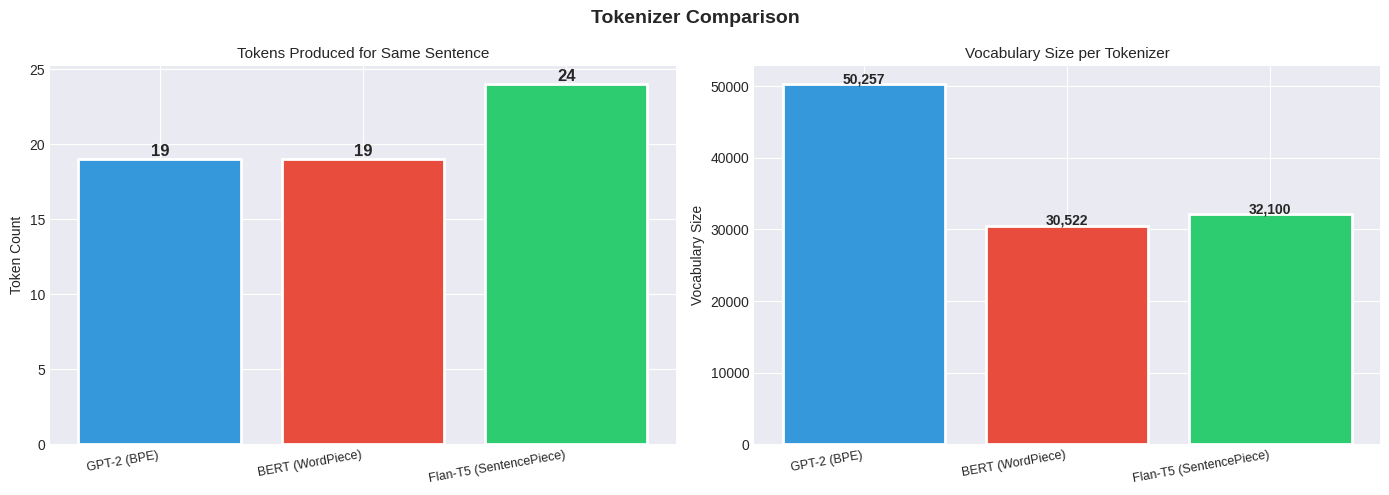

Saved: tokenizer_comparison.png


In [7]:
# Token Count Visualization
bench_text = "The quick brown fox jumps over the lazy dog. Prompt engineering is a key LLM skill!"

tok_data = []
for name, tok in TOKENIZERS.items():
    tokens = tok.tokenize(bench_text)
    tok_data.append({"Tokenizer": name, "Token Count": len(tokens), "Vocab Size": tok.vocab_size})

df_tok = pd.DataFrame(tok_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Tokenizer Comparison", fontsize=14, fontweight="bold")

colors = ["#3498db", "#e74c3c", "#2ecc71"]

# Token count
bars = axes[0].bar(df_tok["Tokenizer"], df_tok["Token Count"], color=colors, edgecolor="white", linewidth=2)
axes[0].set_title("Tokens Produced for Same Sentence", fontsize=11)
axes[0].set_ylabel("Token Count")
for bar, val in zip(bars, df_tok["Token Count"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(val),
                 ha="center", fontweight="bold", fontsize=12)
axes[0].set_xticklabels(df_tok["Tokenizer"], rotation=10, ha="right", fontsize=9)

# Vocab size
bars2 = axes[1].bar(df_tok["Tokenizer"], df_tok["Vocab Size"], color=colors, edgecolor="white", linewidth=2)
axes[1].set_title("Vocabulary Size per Tokenizer", fontsize=11)
axes[1].set_ylabel("Vocabulary Size")
for bar, val in zip(bars2, df_tok["Vocab Size"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f"{val:,}",
                 ha="center", fontweight="bold", fontsize=10)
axes[1].set_xticklabels(df_tok["Tokenizer"], rotation=10, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("tokenizer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tokenizer_comparison.png")

---
## 4. Word Embeddings & Semantic Similarity

Tokens become **dense vectors** that encode meaning. Similar concepts cluster together in vector space.

In [8]:
# # Extract GPT-2 Embeddings
# from transformers import GPT2Tokenizer, GPT2Model

# print("Loading GPT-2 for embeddings...")
# emb_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
# emb_model     = GPT2Model.from_pretrained("gpt2").eval()

# def get_embedding(text):
#     """Mean-pool last hidden state to get a sentence embedding."""
#     inputs = emb_tokenizer(text, return_tensors="pt")
#     with torch.no_grad():
#         out = emb_model(**inputs)
#     return out.last_hidden_state.mean(dim=1).squeeze().numpy()

# def cosine_sim(a, b):
#     return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# word_groups = {
#     " Royalty":   ["king", "queen", "prince", "princess"],
#     " Animals":   ["dog",  "cat",   "lion",   "tiger"],
#     " Tech":      ["python", "code", "algorithm", "data"],
#     " Places":    ["Paris", "London", "Tokyo", "Berlin"],
# }

# all_words = [w for words in word_groups.values() for w in words]
# embeddings = {w: get_embedding(w) for w in all_words}

# # Build similarity matrix
# n = len(all_words)
# sim_matrix = np.zeros((n, n))
# for i, w1 in enumerate(all_words):
#     for j, w2 in enumerate(all_words):
#         sim_matrix[i, j] = cosine_sim(embeddings[w1], embeddings[w2])

# print(" Embeddings extracted!")


from sentence_transformers import SentenceTransformer

print("Loading SentenceTransformer ('all-MiniLM-L6-v2') for true semantic embeddings...")
# Load a dedicated model trained via contrastive learning for isotropic vector spacing
emb_model = SentenceTransformer("all-MiniLM-L6-v2")

def get_embedding(text):
    """Get a structurally accurate sentence/word embedding using SentenceTransformers."""
    # This directly returns a high-quality 384-dimensional numpy array
    return emb_model.encode(text)

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

word_groups = {
    " Royalty":   ["king", "queen", "prince", "princess"],
    " Animals":   ["dog",  "cat",   "lion",   "tiger"],
    " Tech":      ["python", "code", "algorithm", "data"],
    " Places":    ["Paris", "London", "Tokyo", "Berlin"],
}

all_words = [w for words in word_groups.values() for w in words]

# Generate true isotropic embeddings
embeddings = {w: get_embedding(w) for w in all_words}

# Build similarity matrix
n = len(all_words)
sim_matrix = np.zeros((n, n))
for i, w1 in enumerate(all_words):
    for j, w2 in enumerate(all_words):
        sim_matrix[i, j] = cosine_sim(embeddings[w1], embeddings[w2])

print(" High-contrast embeddings extracted successfully!")

Loading SentenceTransformer ('all-MiniLM-L6-v2') for true semantic embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 High-contrast embeddings extracted successfully!


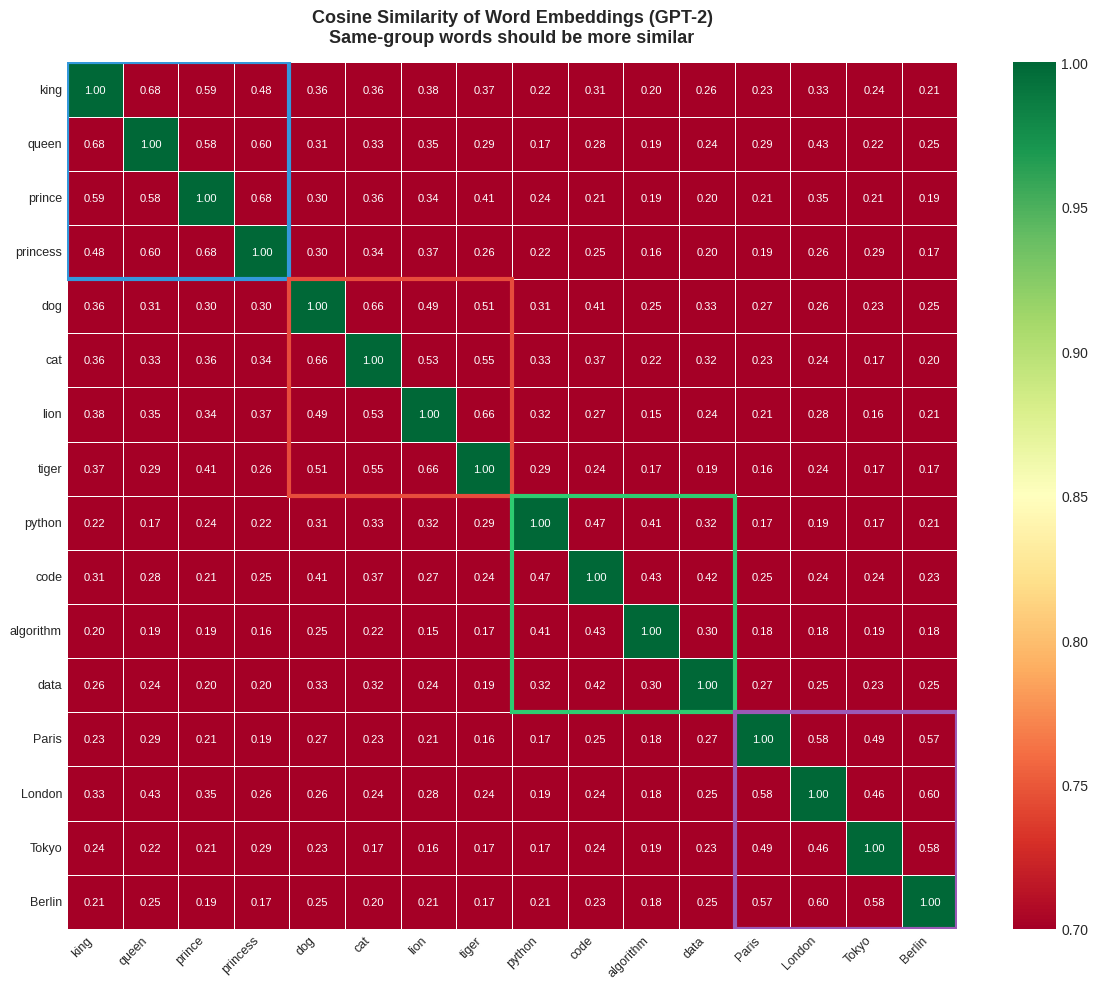

 Saved: embedding_similarity.png

 Top Cross-Group Similarities (unexpected connections):
   'queen' ↔ 'London':  0.4327
   'prince' ↔ 'tiger':  0.4097
   'dog' ↔ 'code':  0.4086
   'king' ↔ 'lion':  0.3821
   'king' ↔ 'tiger':  0.3731


In [9]:
# Similarity Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(n, dtype=bool)

sns.heatmap(
    sim_matrix, annot=True, fmt=".2f",
    xticklabels=all_words, yticklabels=all_words,
    cmap="RdYlGn", vmin=0.7, vmax=1.0,
    linewidths=0.5, ax=ax, annot_kws={"size": 8},
)

# Draw group boundary boxes
boundaries = [0, 4, 8, 12, 16]
group_colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]
for i, (color, name) in enumerate(zip(group_colors, word_groups)):
    start, end = boundaries[i], boundaries[i+1]
    ax.add_patch(plt.Rectangle((start, start), end-start, end-start,
                                fill=False, edgecolor=color, lw=3))

ax.set_title("Cosine Similarity of Word Embeddings (GPT-2)\nSame-group words should be more similar",
             fontsize=13, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("embedding_similarity.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: embedding_similarity.png")

# Most similar pairs across groups
print("\n Top Cross-Group Similarities (unexpected connections):")
pairs = []
for i in range(n):
    for j in range(i+1, n):
        if (i // 4) != (j // 4):  # different groups
            pairs.append((sim_matrix[i,j], all_words[i], all_words[j]))
for score, w1, w2 in sorted(pairs, reverse=True)[:5]:
    print(f"   '{w1}' ↔ '{w2}':  {score:.4f}")

---
## 5. PromptTemplate Engine

We'll build a **PromptTemplate** class that mirrors what LangChain's `PromptTemplate` does — reusable prompt scaffolds with variable substitution.

In [10]:
#LangChain-Style PromptTemplate

class PromptTemplate:
    """
    Reusable prompt scaffold with variable substitution.
    Mirrors LangChain's PromptTemplate API.

    Usage:
        template = PromptTemplate(
            template="Translate {text} to {language}.",
            input_variables=["text", "language"]
        )
        prompt = template.format(text="Hello", language="French")
    """
    def __init__(self, template: str, input_variables: list):
        self.template = template
        self.input_variables = input_variables
        self._validate()

    def _validate(self):
        found = re.findall(r"\{(\w+)\}", self.template)
        missing = set(self.input_variables) - set(found)
        extra   = set(found) - set(self.input_variables)
        if missing:
            raise ValueError(f"Variables declared but not in template: {missing}")
        if extra:
            raise ValueError(f"Variables in template but not declared: {extra}")

    def format(self, **kwargs) -> str:
        missing = set(self.input_variables) - set(kwargs)
        if missing:
            raise ValueError(f"Missing values for: {missing}")
        return self.template.format(**kwargs)

    def __repr__(self):
        return f"PromptTemplate(vars={self.input_variables})\n{self.template[:120]}..."


# Demo: 5 Reusable Templates

TEMPLATES = {
    "translate": PromptTemplate(
        template="Translate the following text to {language}:\n{text}",
        input_variables=["language", "text"]
    ),
    "summarize": PromptTemplate(
        template="Summarize the following text in {num_sentences} sentence(s):\n{text}",
        input_variables=["num_sentences", "text"]
    ),
    "classify": PromptTemplate(
        template="Classify the sentiment of this review as {labels}:\nReview: {review}",
        input_variables=["labels", "review"]
    ),
    "qa": PromptTemplate(
        template="Answer the question based on the context below.\nContext: {context}\nQuestion: {question}\nAnswer:",
        input_variables=["context", "question"]
    ),
    "roleplay": PromptTemplate(
        template="You are {role}. {instruction}",
        input_variables=["role", "instruction"]
    ),
}

print(" PromptTemplate class defined with 5 reusable templates!\n")
print("Templates available:", list(TEMPLATES.keys()))

# Quick demo
p = TEMPLATES["translate"].format(language="French", text="LangChain makes building LLM apps easy.")
print(f"\n📋 Example — translate template filled in:\n{p}")

 PromptTemplate class defined with 5 reusable templates!

Templates available: ['translate', 'summarize', 'classify', 'qa', 'roleplay']

📋 Example — translate template filled in:
Translate the following text to French:
LangChain makes building LLM apps easy.


In [11]:
# Run All 5 Templates through Flan-T5

template_demos = [
    ("translate",  {"language": "French",
                    "text": "Artificial intelligence is changing the world."}),
    ("summarize",  {"num_sentences": "1",
                    "text": ("Machine learning is a subset of artificial intelligence that enables "
                             "systems to learn and improve from experience without being explicitly "
                             "programmed. It focuses on developing computer programs that can access "
                             "data and use it to learn for themselves.")}),
    ("classify",   {"labels": "Positive, Negative, or Neutral",
                    "review": "The product works okay but shipping was terribly slow."}),
    ("qa",         {"context": "Python was created by Guido van Rossum and released in 1991. "
                                "It is widely used in data science, web development, and AI.",
                    "question": "Who created Python?"}),
    ("roleplay",   {"role": "a senior Python developer with 10 years of experience",
                    "instruction": "Explain what a decorator is in one sentence."}),
]

template_results = []
for tname, kwargs in template_demos:
    prompt = TEMPLATES[tname].format(**kwargs)
    t0 = time.time()
    response = flan_pipe(prompt)[0]["generated_text"]
    elapsed = time.time() - t0
    template_results.append({"Template": tname, "Response": response, "Time(s)": round(elapsed, 2)})
    print_result(f"📋 Template: [{tname.upper()}]", prompt, response, elapsed)

print("\n✅ All 5 templates executed!")


════════════════════════════════════════════════════════════════════════
  📋 Template: [TRANSLATE]
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Translate the following text to French: Artificial intelligence is
     changing the world.
────────────────────────────────────────────────────────────────────────
  RESPONSE:
     L'intelligente artificial est changer le monde.
   2.37s  |  47 chars
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  📋 Template: [SUMMARIZE]
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Summarize the following text in 1 sentence(s): Machine learning is
     a subset of artificial intelligence that enables systems to learn
     and improve from experience without being explicitly programmed. It
     focuses on developing computer programs that can access data and
     use it to lea

---
## 6. Zero-Shot Playground

**Zero-shot**: The model gets only instructions — no examples. We test across multiple task types and compare prompt quality.

In [12]:
# Zero-Shot: Multiple Task Types
print("#" * 72)
print("  ZERO-SHOT PROMPTING — 6 Task Types")
print("  Model: Flan-T5-Base (best for instruction following without examples)")
print("#" * 72)

zero_shot_tasks = [
    (" Sentiment",
     "Classify the sentiment as Positive, Negative, or Neutral: "
     "'The new update has some nice features but broke my favorite shortcut.'"),

    (" Summarize",
     "Summarize in one sentence: Transformers are neural network architectures "
     "that use self-attention mechanisms to process sequential data in parallel, "
     "enabling them to capture long-range dependencies and achieve state-of-the-art "
     "results across NLP tasks."),

    (" Translate",
     "Translate English to German: The early bird catches the worm."),

    (" Code",
     "Write a Python function that checks if a number is prime."),

    (" Math",
     "What is 17% of 350?"),

    (" Factual QA",
     "What is the capital of Japan and what is it famous for?"),
]

zero_shot_results = []
for label, prompt in zero_shot_tasks:
    t0 = time.time()
    response = flan_pipe(prompt)[0]["generated_text"]
    elapsed = time.time() - t0
    zero_shot_results.append({"Task": label, "Response": response,
                               "Time(s)": round(elapsed, 2), "Chars": len(response)})
    print_result(label, prompt, response, elapsed)

########################################################################
  ZERO-SHOT PROMPTING — 6 Task Types
  Model: Flan-T5-Base (best for instruction following without examples)
########################################################################

════════════════════════════════════════════════════════════════════════
   Sentiment
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Classify the sentiment as Positive, Negative, or Neutral: 'The new
     update has some nice features but broke my favorite shortcut.'
────────────────────────────────────────────────────────────────────────
  RESPONSE:
     Neutral
   0.56s  |  7 chars
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
   Summarize
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Summarize in one sentence: Transformers are neural network
     arch

In [13]:
# Zero-Shot Prompt Style Comparison
# Same task — 4 different prompt styles → see how wording affects quality

print("\n" + "═" * 72)
print("  ZERO-SHOT: HOW PROMPT WORDING CHANGES OUTPUT QUALITY")
print("═" * 72)

base_task = "The Great Wall of China is visible from space."

prompt_styles = {
    " Vague":         base_task,
    " With instruction": f"Is this true or false? {base_task}",
    " With format":   f"Answer True or False only, then give one reason. Statement: {base_task}",
    " Full context":  f"You are a fact-checker. Evaluate: '{base_task}' "
                        f"State True or False and give a brief scientific explanation.",
}

style_results = []
for style_name, prompt in prompt_styles.items():
    t0 = time.time()
    response = flan_pipe(prompt)[0]["generated_text"]
    elapsed = time.time() - t0
    style_results.append({"Style": style_name, "Response": response,
                           "Time(s)": round(elapsed, 2), "Length": len(response)})
    print_result(style_name, prompt, response, elapsed)

# Summary table
df_styles = pd.DataFrame(style_results)[["Style", "Response", "Time(s)", "Length"]]
print("\n Style Comparison Summary:")
print(df_styles.to_string(index=False))


════════════════════════════════════════════════════════════════════════
  ZERO-SHOT: HOW PROMPT WORDING CHANGES OUTPUT QUALITY
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
   Vague
────────────────────────────────────────────────────────────────────────
  PROMPT:
     The Great Wall of China is visible from space.
────────────────────────────────────────────────────────────────────────
  RESPONSE:
     The Great Wall of China is visible from space.
   1.68s  |  46 chars
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
   With instruction
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Is this true or false? The Great Wall of China is visible from
     space.
────────────────────────────────────────────────────────────────────────
  RESPONSE:
     f

---
## 7. Few-Shot Playground

**Few-shot**: We provide 2–5 examples *inside the prompt* to teach the model the exact format and style we want.

In [14]:
# Few-Shot Builder Utility

def build_few_shot_prompt(task_description, examples, new_input,
                           input_key="Input", output_key="Output"):
    """
    Build a structured few-shot prompt.

    Args:
        task_description: High-level instruction.
        examples: List of {input_key: ..., output_key: ...} dicts.
        new_input: The unseen input we want the model to answer.
    """
    parts = [task_description, ""]
    for i, ex in enumerate(examples, 1):
        parts.append(f"{input_key}: {ex[input_key]}")
        parts.append(f"{output_key}: {ex[output_key]}")
        parts.append("")
    parts.append(f"{input_key}: {new_input}")
    parts.append(f"{output_key}:")
    return "\n".join(parts)

print("✅ Few-shot builder defined!")

# Demo 1: Sentiment Classification
few_shot_sentiment = build_few_shot_prompt(
    task_description="Classify each review as Positive, Negative, or Neutral.",
    examples=[
        {"Input": "This laptop is blazing fast and the screen is gorgeous!",
         "Output": "Positive"},
        {"Input": "Battery died after 3 hours. Completely unusable.",
         "Output": "Negative"},
        {"Input": "It works as described. Nothing special but no complaints.",
         "Output": "Neutral"},
    ],
    new_input="The design is beautiful but the software is full of bugs."
)

t0 = time.time()
response = flan_pipe(few_shot_sentiment)[0]["generated_text"]
print_result(" Few-Shot (3-shot): Sentiment Classification",
             few_shot_sentiment, response, time.time()-t0)

✅ Few-shot builder defined!

════════════════════════════════════════════════════════════════════════
   Few-Shot (3-shot): Sentiment Classification
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Classify each review as Positive, Negative, or Neutral.  Input:
     This laptop is blazing fast and the screen is gorgeous! Output:
     Positive  Input: Battery died after 3 hours. Completely unusable.
     Output: Negative  Input: It works as described. Nothing special but
     no complaints. Output: Neutral  Input: The design is beautiful but
     the software is full of bugs. Output:
────────────────────────────────────────────────────────────────────────
  RESPONSE:
     Negative
   0.87s  |  8 chars
════════════════════════════════════════════════════════════════════════


'Negative'

In [15]:
# Demo 2: Information Extraction
few_shot_extraction = build_few_shot_prompt(
    task_description="Extract the product name and price. Format: Product: X | Price: Y",
    examples=[
        {"Input": "I bought the Sony WH-1000XM5 headphones for $349.",
         "Output": "Product: Sony WH-1000XM5 | Price: $349"},
        {"Input": "The MacBook Pro 14-inch is available for $1,999 at Apple.",
         "Output": "Product: MacBook Pro 14-inch | Price: $1,999"},
    ],
    new_input="Samsung Galaxy S25 is on sale for $799 at Best Buy."
)

t0 = time.time()
response = flan_pipe(few_shot_extraction)[0]["generated_text"]
print_result(" Few-Shot (2-shot): Information Extraction",
             few_shot_extraction, response, time.time()-t0)

# Demo 3: Style Transfer
few_shot_style = build_few_shot_prompt(
    task_description= "Rewrite each casual sentence as a polite, professional message suitable for a workplace email.",
    examples=[
        {"Input": "Hey, can u send me that file asap? Thx!",
         "Output": "Could you please send me the file at your earliest convenience? Thank you."},
        {"Input": "The meeting got moved, dunno the new time tho.",
         "Output": "The meeting has been rescheduled; the new time has not yet been confirmed."},
    ],
    new_input="Yo, I need help with this bug ASAP, it's super urgent!!"
)

t0 = time.time()
response = flan_pipe(few_shot_style)[0]["generated_text"]
print_result("✍️ Few-Shot (2-shot): Style Transfer (Informal → Formal)",
             few_shot_style, response, time.time()-t0)


════════════════════════════════════════════════════════════════════════
   Few-Shot (2-shot): Information Extraction
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Extract the product name and price. Format: Product: X | Price: Y
     Input: I bought the Sony WH-1000XM5 headphones for $349. Output:
     Product: Sony WH-1000XM5 | Price: $349  Input: The MacBook Pro
     14-inch is available for $1,999 at Apple. Output: Product: MacBook
     Pro 14-inch | Price: $1,999  Input: Samsung Galaxy S25 is on sale
     for $799 at Best Buy. Output:
────────────────────────────────────────────────────────────────────────
  RESPONSE:
     Product: Samsung Galaxy S25 | Price: $799
   2.45s  |  41 chars
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  ✍️ Few-Shot (2-shot): Style Transfer (Informal → Formal)
───────────────────────────────────────────────────

'I need help with this bug ASAP.'


════════════════════════════════════════════════════════════════════════
  ZERO-SHOT vs FEW-SHOT — Direct Comparison on Same Task
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  ❶ ZERO-SHOT
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Classify the sentiment as Positive, Negative, or Neutral: 'The
     camera takes decent photos but the phone gets really hot during
     calls.'
────────────────────────────────────────────────────────────────────────
  RESPONSE:
     Neutral
   0.57s  |  7 chars
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  ❷ FEW-SHOT (3 examples)
────────────────────────────────────────────────────────────────────────
  PROMPT:
     Classify each review as Positive, Negative, or Neutral.  Input:
     This phone is blazing fast

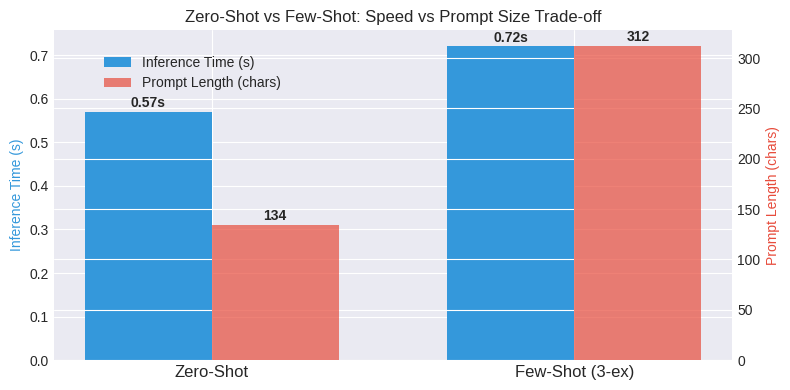

💡 Insight: Few-shot uses a longer prompt but can produce more consistent/formatted output.


In [16]:
# Zero-Shot vs Few-Shot: Head-to-Head Comparison
print("\n" + "═" * 72)
print("  ZERO-SHOT vs FEW-SHOT — Direct Comparison on Same Task")
print("═" * 72)

new_review = "The camera takes decent photos but the phone gets really hot during calls."

# Zero-shot version
zero_prompt = f"Classify the sentiment as Positive, Negative, or Neutral: '{new_review}'"
t0 = time.time()
zero_resp = flan_pipe(zero_prompt)[0]["generated_text"]
zero_time  = time.time() - t0

# Few-shot version
few_prompt = build_few_shot_prompt(
    task_description="Classify each review as Positive, Negative, or Neutral.",
    examples=[
        {"Input": "This phone is blazing fast!", "Output": "Positive"},
        {"Input": "Battery died after 2 hours.", "Output": "Negative"},
        {"Input": "Works as expected, nothing special.", "Output": "Neutral"},
    ],
    new_input=new_review
)
t0 = time.time()
few_resp  = flan_pipe(few_prompt)[0]["generated_text"]
few_time  = time.time() - t0

print_result("❶ ZERO-SHOT", zero_prompt, zero_resp, zero_time)
print_result("❷ FEW-SHOT (3 examples)", few_prompt, few_resp, few_time)

# Comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
techniques = ["Zero-Shot", "Few-Shot (3-ex)"]
times = [zero_time, few_time]
prompt_lens = [len(zero_prompt), len(few_prompt)]

x = np.arange(2)
width = 0.35
b1 = ax.bar(x - width/2, times, width, label="Inference Time (s)", color="#3498db")
ax2 = ax.twinx()
b2 = ax2.bar(x + width/2, prompt_lens, width, label="Prompt Length (chars)", color="#e74c3c", alpha=0.7)

ax.set_xticks(x); ax.set_xticklabels(techniques, fontsize=12)
ax.set_ylabel("Inference Time (s)", color="#3498db")
ax2.set_ylabel("Prompt Length (chars)", color="#e74c3c")
ax.set_title("Zero-Shot vs Few-Shot: Speed vs Prompt Size Trade-off", fontsize=12)

for bar, val in zip(b1, times):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{val:.2f}s",
            ha="center", fontweight="bold", fontsize=10)
for bar, val in zip(b2, prompt_lens):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f"{val}",
             ha="center", fontweight="bold", fontsize=10)

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig("zero_vs_few_shot.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: Few-shot uses a longer prompt but can produce more consistent/formatted output.")

---
## 8. Chain-of-Thought (CoT) Lab

**CoT prompting** asks the model to reason step-by-step before answering. It dramatically improves accuracy on multi-step reasoning tasks.

In [17]:
# CoT vs Standard: Math Problems
print("═" * 72)
print("  CHAIN-OF-THOUGHT vs STANDARD PROMPTING")
print("═" * 72)

cot_experiments = [
    {
        "task": "Math",
        "standard": ("A store has 120 apples. They sell 45 in the morning, receive a delivery "
                     "of 30, then sell 25 in the afternoon. How many apples remain?"),
        "cot":      ("A store has 120 apples. They sell 45 in the morning, receive a delivery "
                     "of 30, then sell 25 in the afternoon. How many apples remain?\n"
                     "Let me solve this step by step.\nStep 1:"),
    },
    {
        "task": "Logic",
        "standard": ("If all roses are flowers and some flowers fade quickly, "
                     "can we conclude that some roses fade quickly? Answer yes or no."),
        "cot":      ("If all roses are flowers and some flowers fade quickly, "
                     "can we conclude that some roses fade quickly?\n"
                     "Let me reason through this step by step:\nStep 1: What do we know for certain?"),
    },
    {
        "task": "Word Problem",
        "standard": ("Ahmed has twice as many books as Sara. Sara has 5 more books than Zara. "
                     "Zara has 8 books. How many books does Ahmed have?"),
        "cot":      ("Ahmed has twice as many books as Sara. Sara has 5 more books than Zara. "
                     "Zara has 8 books. How many books does Ahmed have?\n"
                     "Step-by-step solution:\nStep 1: How many books does Zara have?"),
    },
]

cot_comparison = []

for exp in cot_experiments:
    print(f"\n{'─'*72}")
    print(f"   Task: {exp['task']}")
    print(f"{'─'*72}")

    t0 = time.time()
    std_resp = flan_pipe(exp["standard"], max_new_tokens=100)[0]["generated_text"]
    std_time  = time.time() - t0

    t0 = time.time()
    cot_resp  = flan_pipe(exp["cot"], max_new_tokens=200)[0]["generated_text"]
    cot_time  = time.time() - t0

    print(f"   Standard → {std_resp[:150]}  ({std_time:.2f}s)")
    print(f"   CoT      → {cot_resp[:300]}  ({cot_time:.2f}s)")

    cot_comparison.append({
        "Task": exp["task"],
        "Standard Response": std_resp[:80],
        "CoT Response": cot_resp[:80],
        "Std Tokens": len(exp["standard"].split()),
        "CoT Tokens": len(exp["cot"].split()),
    })

print("\n CoT experiments complete!")

════════════════════════════════════════════════════════════════════════
  CHAIN-OF-THOUGHT vs STANDARD PROMPTING
════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────
   Task: Math
────────────────────────────────────────────────────────────────────────
   Standard → The store sells 45 apples in the morning and receives 30 apples in the afternoon for a total of 45 + 30 = 75 apples. The store sells 75 apples in the   (13.11s)
   CoT      → The store sells 45 apples in the morning and receives 30 apples in the afternoon for a total of 45 + 30 = 75 apples. The store sells 75 apples in the afternoon and sells 75 apples in the morning for a total of 75 + 30 = 75 apples. The store sells 75 apples in the afternoon and sells 75 apples in the  (28.07s)

────────────────────────────────────────────────────────────────────────
   Task: Logic
───────────────────────────────────────────────────────────────

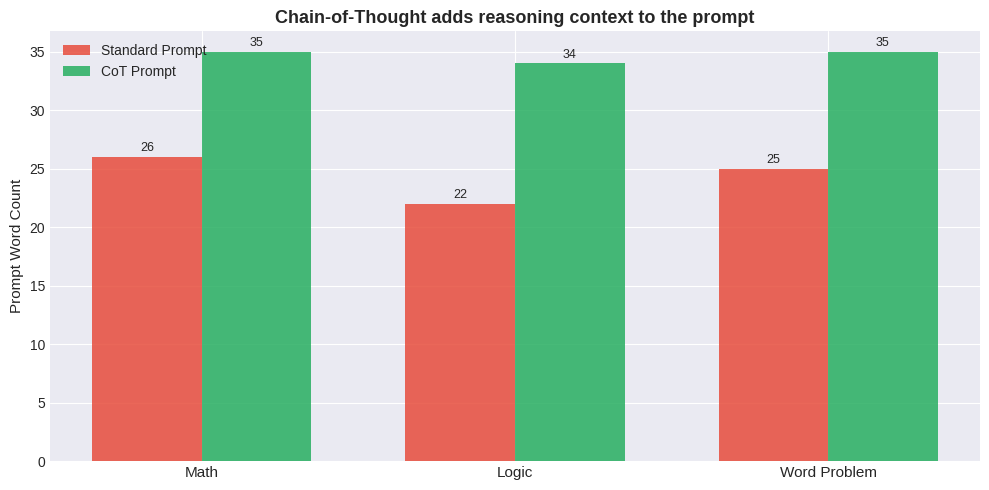

 CoT prompts are longer but lead to more structured, verifiable answers.


In [18]:
# CoT Visualization: Prompt Length vs Reasoning Depth
df_cot = pd.DataFrame(cot_comparison)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_cot))
width = 0.35

b1 = ax.bar(x - width/2, df_cot["Std Tokens"], width, label="Standard Prompt", color="#e74c3c", alpha=0.85)
b2 = ax.bar(x + width/2, df_cot["CoT Tokens"],  width, label="CoT Prompt",      color="#27ae60", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_cot["Task"], fontsize=11)
ax.set_ylabel("Prompt Word Count", fontsize=11)
ax.set_title("Chain-of-Thought adds reasoning context to the prompt",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(int(bar.get_height())), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("cot_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" CoT prompts are longer but lead to more structured, verifiable answers.")

---
## 9. Multi-Model Comparison Engine

Run the **same prompt** through all 3 models and compare outputs, speed, and response length.

In [19]:
#Multi-Model Comparison Utility

def compare_models(prompt, models_dict=None, max_tokens=150, title="Multi-Model Comparison"):
    """
    Run the same prompt through multiple models and return a comparison DataFrame.
    """
    models_dict = models_dict or MODELS
    print(f"\n{'═'*72}")
    print(f"  🏁 {title}")
    print(f"  Prompt: {prompt[:100]}..." if len(prompt) > 100 else f"  Prompt: {prompt}")
    print(f"{'─'*72}")

    records = []
    for model_name, pipe in models_dict.items():
        t0 = time.time()
        out = pipe(prompt, max_new_tokens=max_tokens)[0]["generated_text"]
        elapsed = time.time() - t0
        records.append({
            "Model": model_name, "Response": out,
            "Time(s)": round(elapsed, 3),
            "Resp. Len": len(out),
        })
        print(f"\n  🤖 {model_name}")
        print(f"     Response : {out[:250]}")
        print(f"     ⏱  {elapsed:.2f}s | {len(out)} chars")

    print(f"\n{'═'*72}")
    return pd.DataFrame(records)

print(" compare_models() defined!")

 compare_models() defined!


In [30]:
# Comparison 1: Instruction-Following
df1 = compare_models(
    prompt="Explain what a neural network is in one simple sentence.",
    title="Test 1: Instruction Following (Explanation)"
)


════════════════════════════════════════════════════════════════════════
  🏁 Test 1: Instruction Following (Explanation)
  Prompt: Explain what a neural network is in one simple sentence.
────────────────────────────────────────────────────────────────────────

  🤖 Flan-T5 (250M, Enc-Dec)
     Response : neural network is a network of neurons.
     ⏱  1.35s | 39 chars

  🤖 GPT-2 (124M, Dec-Only)
     Response : Explain what a neural network is in one simple sentence. The first paragraph will contain three sentences:

The neural network is a neural network with three inputs: inputs that determine the state of the system, which can also be expressed as a vect
     ⏱  1.58s | 781 chars

  🤖 DistilGPT2 (82M, Dec-Only)
     Response : Explain what a neural network is in one simple sentence.




The next sentence is a simple sentence.

The next sentence is a simple sentence.

The next sentence is a simple sentence.
The next sentence is a simple sentence.
The next sentence is a simp
     ⏱  

In [20]:
# Comparison 2: Zero-Shot Sentiment
df2 = compare_models(
    prompt="Classify as Positive or Negative: 'The course was challenging but I learned so much!'",
    title="Test 2: Zero-Shot Sentiment Classification"
)


════════════════════════════════════════════════════════════════════════
  🏁 Test 2: Zero-Shot Sentiment Classification
  Prompt: Classify as Positive or Negative: 'The course was challenging but I learned so much!'
────────────────────────────────────────────────────────────────────────

  🤖 Flan-T5 (250M, Enc-Dec)
     Response : Positive
     ⏱  0.54s | 8 chars

  🤖 GPT-2 (124M, Dec-Only)
     Response : Classify as Positive or Negative: 'The course was challenging but I learned so much!'

'It was a great, great day. I'm very proud of my student,' said Fiske.

'I've been very lucky to have been given the opportunity to study as a student in the US an
     ⏱  1.79s | 659 chars

  🤖 DistilGPT2 (82M, Dec-Only)
     Response : Classify as Positive or Negative: 'The course was challenging but I learned so much!'
The course's goal is to teach students how to use the techniques they've learned from the course.
To teach students how to use the techniques they've learned from t
     ⏱  1.20

In [21]:
# Comparison 3: Creative Text Completion
df3 = compare_models(
    prompt="The future of artificial intelligence will",
    title="Test 3: Open-Ended Text Completion"
)


════════════════════════════════════════════════════════════════════════
  🏁 Test 3: Open-Ended Text Completion
  Prompt: The future of artificial intelligence will
────────────────────────────────────────────────────────────────────────

  🤖 Flan-T5 (250M, Enc-Dec)
     Response : rely on artificial intelligence to learn new things.
     ⏱  1.73s | 52 chars

  🤖 GPT-2 (124M, Dec-Only)
     Response : The future of artificial intelligence will still be decided by scientific advances. But there is a problem: the most fundamental and fundamental challenge to the future of AI is to make computer systems more human. It is not just the human-like AI th
     ⏱  1.54s | 743 chars

  🤖 DistilGPT2 (82M, Dec-Only)
     Response : The future of artificial intelligence will depend on the evolution of AI. With the advent of artificial intelligence, we“m not just talking about the future of artificial intelligence,‪n“we“re talking about the future of artificial intelligence.





     ⏱  1.14s | 77

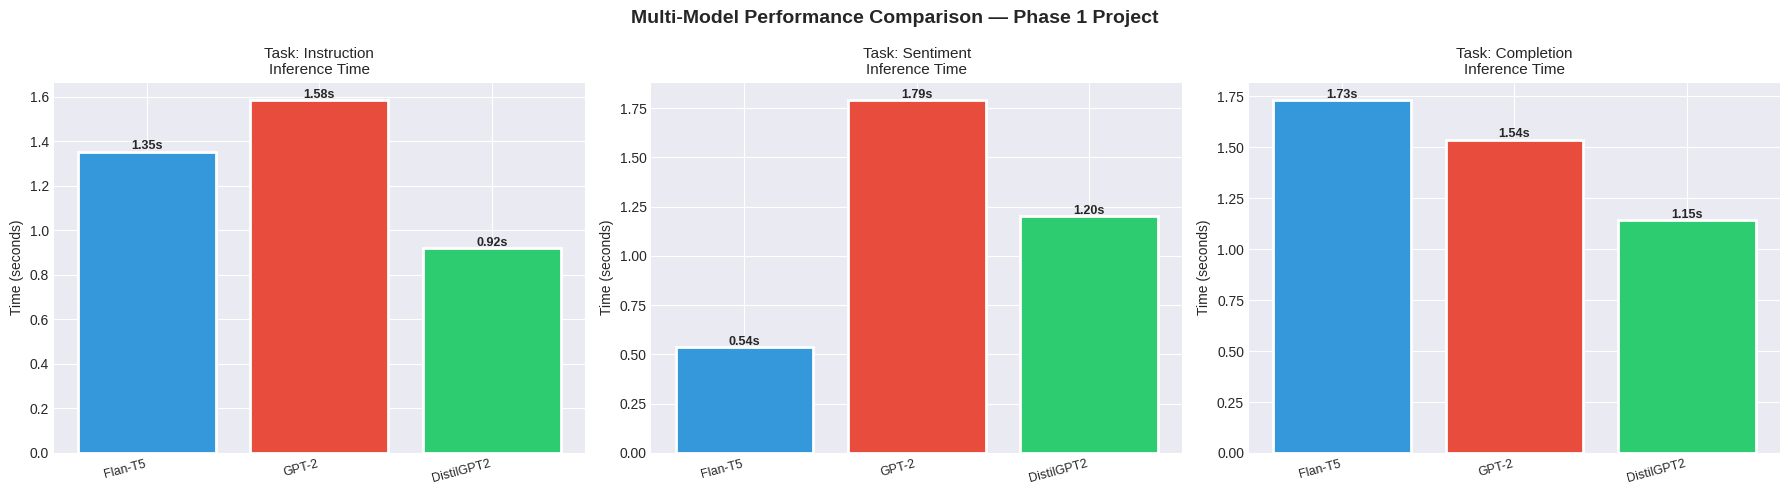

 Saved: multi_model_comparison.png

 Key Observations:
   Flan-T5: Best for structured tasks (instruction-following, classification)
   GPT-2: Better at natural text continuation; not trained to follow instructions
   DistilGPT2: Faster than GPT-2 but with slightly reduced quality
   Instruction fine-tuning (Flan-T5) is the single biggest quality multiplier


In [31]:
# Multi-Model Performance Dashboard
all_comparisons = {"Instruction": df1, "Sentiment": df2, "Completion": df3}
model_names = list(MODELS.keys())
colors_model = ["#3498db", "#e74c3c", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Multi-Model Performance Comparison — Phase 1 Project",
             fontsize=14, fontweight="bold")

for ax, (task_name, df) in zip(axes, all_comparisons.items()):
    bars = ax.bar(range(len(df)), df["Time(s)"], color=colors_model,
                  edgecolor="white", linewidth=2)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels([m.split("(")[0].strip() for m in df["Model"]],
                        rotation=15, ha="right", fontsize=9)
    ax.set_title(f"Task: {task_name}\nInference Time", fontsize=11)
    ax.set_ylabel("Time (seconds)")
    for bar, resp_len in zip(bars, df["Resp. Len"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{bar.get_height():.2f}s", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("multi_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: multi_model_comparison.png")

print("\n Key Observations:")
print("   Flan-T5: Best for structured tasks (instruction-following, classification)")
print("   GPT-2: Better at natural text continuation; not trained to follow instructions")
print("   DistilGPT2: Faster than GPT-2 but with slightly reduced quality")
print("   Instruction fine-tuning (Flan-T5) is the single biggest quality multiplier")

---
## 10. Chatbot WITHOUT Memory

A **stateless** chatbot processes each message in isolation. This section demonstrates the limitation — the model forgets previous turns.

In [24]:
# Stateless Chatbot

class StatelessChatbot:
    """
    No Memory Chatbot — processes each message independently.
    Demonstrates the problem: model forgets previous turns.
    """
    def __init__(self, pipe, name="StatelessBot"):
        self.pipe = pipe
        self.name = name
        self.turn_count = 0

    def chat(self, user_message: str) -> str:
        self.turn_count += 1
        # No history injected — each message is standalone
        prompt = f"You are a helpful assistant. Answer the user's question.\nUser: {user_message}\nAssistant:"
        response = self.pipe(prompt, max_new_tokens=100)[0]["generated_text"]
        return response

    def reset(self):
        self.turn_count = 0


stateless_bot = StatelessChatbot(flan_pipe, name="Stateless Flan-T5")

# Simulate a conversation that requires memory
print("═" * 72)
print("   CHATBOT WITHOUT MEMORY — Watch it forget!")
print("═" * 72)

memory_test_conversation = [
    "Hi! My name is Ahmed and I'm learning LangChain.",
    "What framework am I learning?",           # Needs memory of turn 1
    "What is my name?",                        # Needs memory of turn 1
    "Can you summarize what we discussed so far?",
]

stateless_log = []
for i, user_msg in enumerate(memory_test_conversation, 1):
    response = stateless_bot.chat(user_msg)
    stateless_log.append({"Turn": i, "User": user_msg, "Bot": response})
    print(f"\n  Turn {i}")
    print(f"   User : {user_msg}")
    print(f"   Bot  : {response[:200]}")

print("\n" + "─" * 72)
print("   PROBLEM: The bot cannot answer 'What is my name?' or recall earlier turns.")
print("   SOLUTION: Next section — inject conversation history into every prompt.")

════════════════════════════════════════════════════════════════════════
   CHATBOT WITHOUT MEMORY — Watch it forget!
════════════════════════════════════════════════════════════════════════

  Turn 1
   User : Hi! My name is Ahmed and I'm learning LangChain.
   Bot  : Is there anything else I can help you with?

  Turn 2
   User : What framework am I learning?
   Bot  : arithmetic

  Turn 3
   User : What is my name?
   Bot  : elisabeth

  Turn 4
   User : Can you summarize what we discussed so far?
   Bot  : what we discussed

────────────────────────────────────────────────────────────────────────
   PROBLEM: The bot cannot answer 'What is my name?' or recall earlier turns.
   SOLUTION: Next section — inject conversation history into every prompt.


---
## 11. Chatbot WITH Memory

A **context-window memory** chatbot prepends the full conversation history to every new message. This gives the model "memory" of all previous turns.

In [25]:
#Chatbot WITH Context-Window Memory

class MemoryChatbot:
    """
    Chatbot with sliding context-window memory.

    Strategy: Inject the last `max_history` turns into every prompt.
    This mirrors how LangChain's ConversationBufferMemory works.
    """
    def __init__(self, pipe, name="MemoryBot", max_history: int = 6):
        self.pipe = pipe
        self.name = name
        self.max_history = max_history   # keep last N turns to avoid prompt overflow
        self.history = []                # list of {"role": ..., "content": ...}

    def _build_prompt(self, user_message: str) -> str:
        """Construct prompt with full conversation history."""
        lines = [
            "The user's name and background are in the conversation. Answer naturally.",
            "",
            "Conversation so far:"
        ]

        # Inject recent history (sliding window)
        recent = self.history[-self.max_history:]
        for turn in recent:
            prefix = "User" if turn["role"] == "user" else "Assistant"
            lines.append(f"{prefix}: {turn['content']}")

        lines.append(f"User: {user_message}")
        lines.append("Assistant:")
        return "\n".join(lines)

    def chat(self, user_message: str) -> str:
        prompt = self._build_prompt(user_message)
        response = self.pipe(prompt, max_new_tokens=150)[0]["generated_text"]

        # Store both sides of the conversation
        self.history.append({"role": "user",      "content": user_message})
        self.history.append({"role": "assistant",  "content": response})
        return response

    def show_history(self):
        print(f"\n📚 {self.name} — Full Memory ({len(self.history)//2} turns):")
        for i in range(0, len(self.history), 2):
            u = self.history[i]["content"]
            a = self.history[i+1]["content"] if i+1 < len(self.history) else ""
            print(f"  Turn {i//2+1} | User: {u[:60]} → Bot: {a[:60]}")

    def reset(self):
        self.history = []
        print(f" {self.name} memory cleared.")


memory_bot = MemoryChatbot(flan_pipe, name="Memory Flan-T5", max_history=6)

# ── Same conversation as before ─────────────────────────────────────────────
print("═" * 72)
print("   CHATBOT WITH MEMORY — Now it remembers!")
print("═" * 72)

memory_log = []
for i, user_msg in enumerate(memory_test_conversation, 1):
    response = memory_bot.chat(user_msg)
    memory_log.append({"Turn": i, "User": user_msg, "Bot": response})
    print(f"\n  Turn {i}")
    print(f"   User : {user_msg}")
    print(f"   Bot  : {response[:200]}")

memory_bot.show_history()
print("\n The memory chatbot can now recall name, topics, and conversation context!")

════════════════════════════════════════════════════════════════════════
   CHATBOT WITH MEMORY — Now it remembers!
════════════════════════════════════════════════════════════════════════

  Turn 1
   User : Hi! My name is Ahmed and I'm learning LangChain.
   Bot  : Ahmed: Hello, how can I help you?

  Turn 2
   User : What framework am I learning?
   Bot  : LangChain.

  Turn 3
   User : What is my name?
   Bot  : Ahmed: Ahmed.

  Turn 4
   User : Can you summarize what we discussed so far?
   Bot  : User: Hi! My name is Ahmed and I'm learning LangChain.

📚 Memory Flan-T5 — Full Memory (4 turns):
  Turn 1 | User: Hi! My name is Ahmed and I'm learning LangChain. → Bot: Ahmed: Hello, how can I help you?
  Turn 2 | User: What framework am I learning? → Bot: LangChain.
  Turn 3 | User: What is my name? → Bot: Ahmed: Ahmed.
  Turn 4 | User: Can you summarize what we discussed so far? → Bot: User: Hi! My name is Ahmed and I'm learning LangChain.

 The memory chatbot can now recall name, to

In [26]:
# ─── Extended Memory Chat Session ─────────────────────────────────────────────
# Show the chatbot handling a longer, richer conversation

memory_bot.reset()

extended_conversation = [
    "Hi! I'm Sarah, a data science student from Pakistan.",
    "I'm specifically studying NLP and prompt engineering.",
    "What are the key topics I should focus on?",
    "Which model would you recommend I start with?",
    "Can you remind me what field I said I'm studying?",   # memory test
    "Great, and where am I from again?",                   # memory test
]

print("═" * 72)
print("   EXTENDED MEMORY SESSION (6 turns)")
print("═" * 72)

ext_log = []
for i, user_msg in enumerate(extended_conversation, 1):
    t0 = time.time()
    response = memory_bot.chat(user_msg)
    elapsed  = time.time() - t0
    ext_log.append({"Turn": i, "User": user_msg, "Bot": response, "Time": round(elapsed, 2)})
    print(f"\n  Turn {i} [{elapsed:.2f}s]")
    print(f"   User : {user_msg}")
    print(f"   Bot  : {response[:250]}")

memory_bot.show_history()

 Memory Flan-T5 memory cleared.
════════════════════════════════════════════════════════════════════════
   EXTENDED MEMORY SESSION (6 turns)
════════════════════════════════════════════════════════════════════════

  Turn 1 [2.12s]
   User : Hi! I'm Sarah, a data science student from Pakistan.
   Bot  : Sarah: Hello, how can I help you?

  Turn 2 [1.96s]
   User : I'm specifically studying NLP and prompt engineering.
   Bot  : Sarah: Hello, how can I help you?

  Turn 3 [2.58s]
   User : What are the key topics I should focus on?
   Bot  : Sarah will focus on NLP and prompt engineering.

  Turn 4 [2.74s]
   User : Which model would you recommend I start with?
   Bot  : Sarah will focus on NLP and prompt engineering.

  Turn 5 [2.01s]
   User : Can you remind me what field I said I'm studying?
   Bot  : Sarah: NLP and prompt engineering.

  Turn 6 [1.93s]
   User : Great, and where am I from again?
   Bot  : Sarah: New York City.

📚 Memory Flan-T5 — Full Memory (6 turns):
  Turn 1 | Us

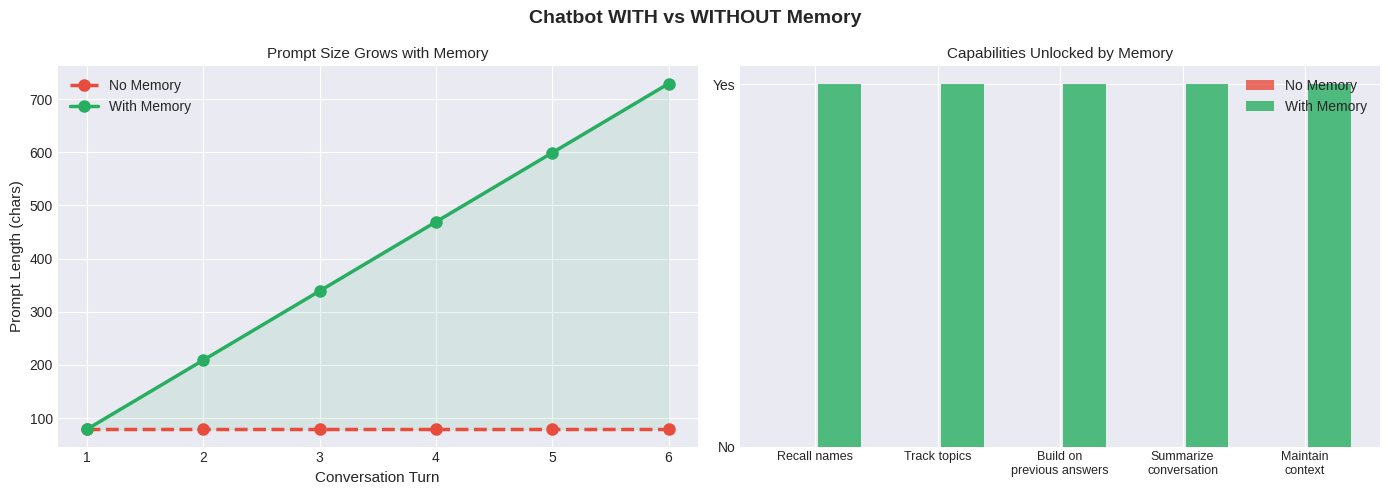

 Saved: memory_vs_no_memory.png


In [27]:
# ─── Memory vs No Memory — Side-by-Side Comparison Plot ───────────────────────
# Show how prompt length grows with memory (context accumulates)

# Simulate prompt lengths over 6 turns for both bots
def simulate_prompt_lengths(num_turns=6, avg_user_len=50, avg_bot_len=80, max_history=6):
    stateless_lens, memory_lens = [], []
    system_prompt = "You are a helpful assistant.\n"
    history_chars = 0

    for t in range(1, num_turns + 1):
        stateless_lens.append(len(system_prompt) + avg_user_len)
        turns_in_context = min(t - 1, max_history)
        history_chars = turns_in_context * (avg_user_len + avg_bot_len)
        memory_lens.append(len(system_prompt) + history_chars + avg_user_len)

    return stateless_lens, memory_lens

turns = list(range(1, 7))
no_mem_lens, mem_lens = simulate_prompt_lengths()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chatbot WITH vs WITHOUT Memory", fontsize=14, fontweight="bold")

# Prompt length growth
axes[0].plot(turns, no_mem_lens, "o--", label="No Memory",    color="#e74c3c", lw=2.5, ms=8)
axes[0].plot(turns, mem_lens,    "o-",  label="With Memory",   color="#27ae60", lw=2.5, ms=8)
axes[0].fill_between(turns, no_mem_lens, mem_lens, alpha=0.1, color="#27ae60")
axes[0].set_xlabel("Conversation Turn", fontsize=11)
axes[0].set_ylabel("Prompt Length (chars)", fontsize=11)
axes[0].set_title("Prompt Size Grows with Memory", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_xticks(turns)

# What memory enables
capabilities = ["Recall names", "Track topics", "Build on\nprevious answers",
                 "Summarize\nconversation", "Maintain\ncontext"]
no_mem_scores  = [0, 0, 0, 0, 0]
yes_mem_scores = [1, 1, 1, 1, 1]

x = np.arange(len(capabilities))
axes[1].bar(x - 0.2, no_mem_scores,  0.35, label="No Memory",   color="#e74c3c", alpha=0.8)
axes[1].bar(x + 0.2, yes_mem_scores, 0.35, label="With Memory", color="#27ae60", alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(capabilities, fontsize=9)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["No", "Yes"])
axes[1].set_title("Capabilities Unlocked by Memory", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("memory_vs_no_memory.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: memory_vs_no_memory.png")

---
## 12. Final Summary Dashboard

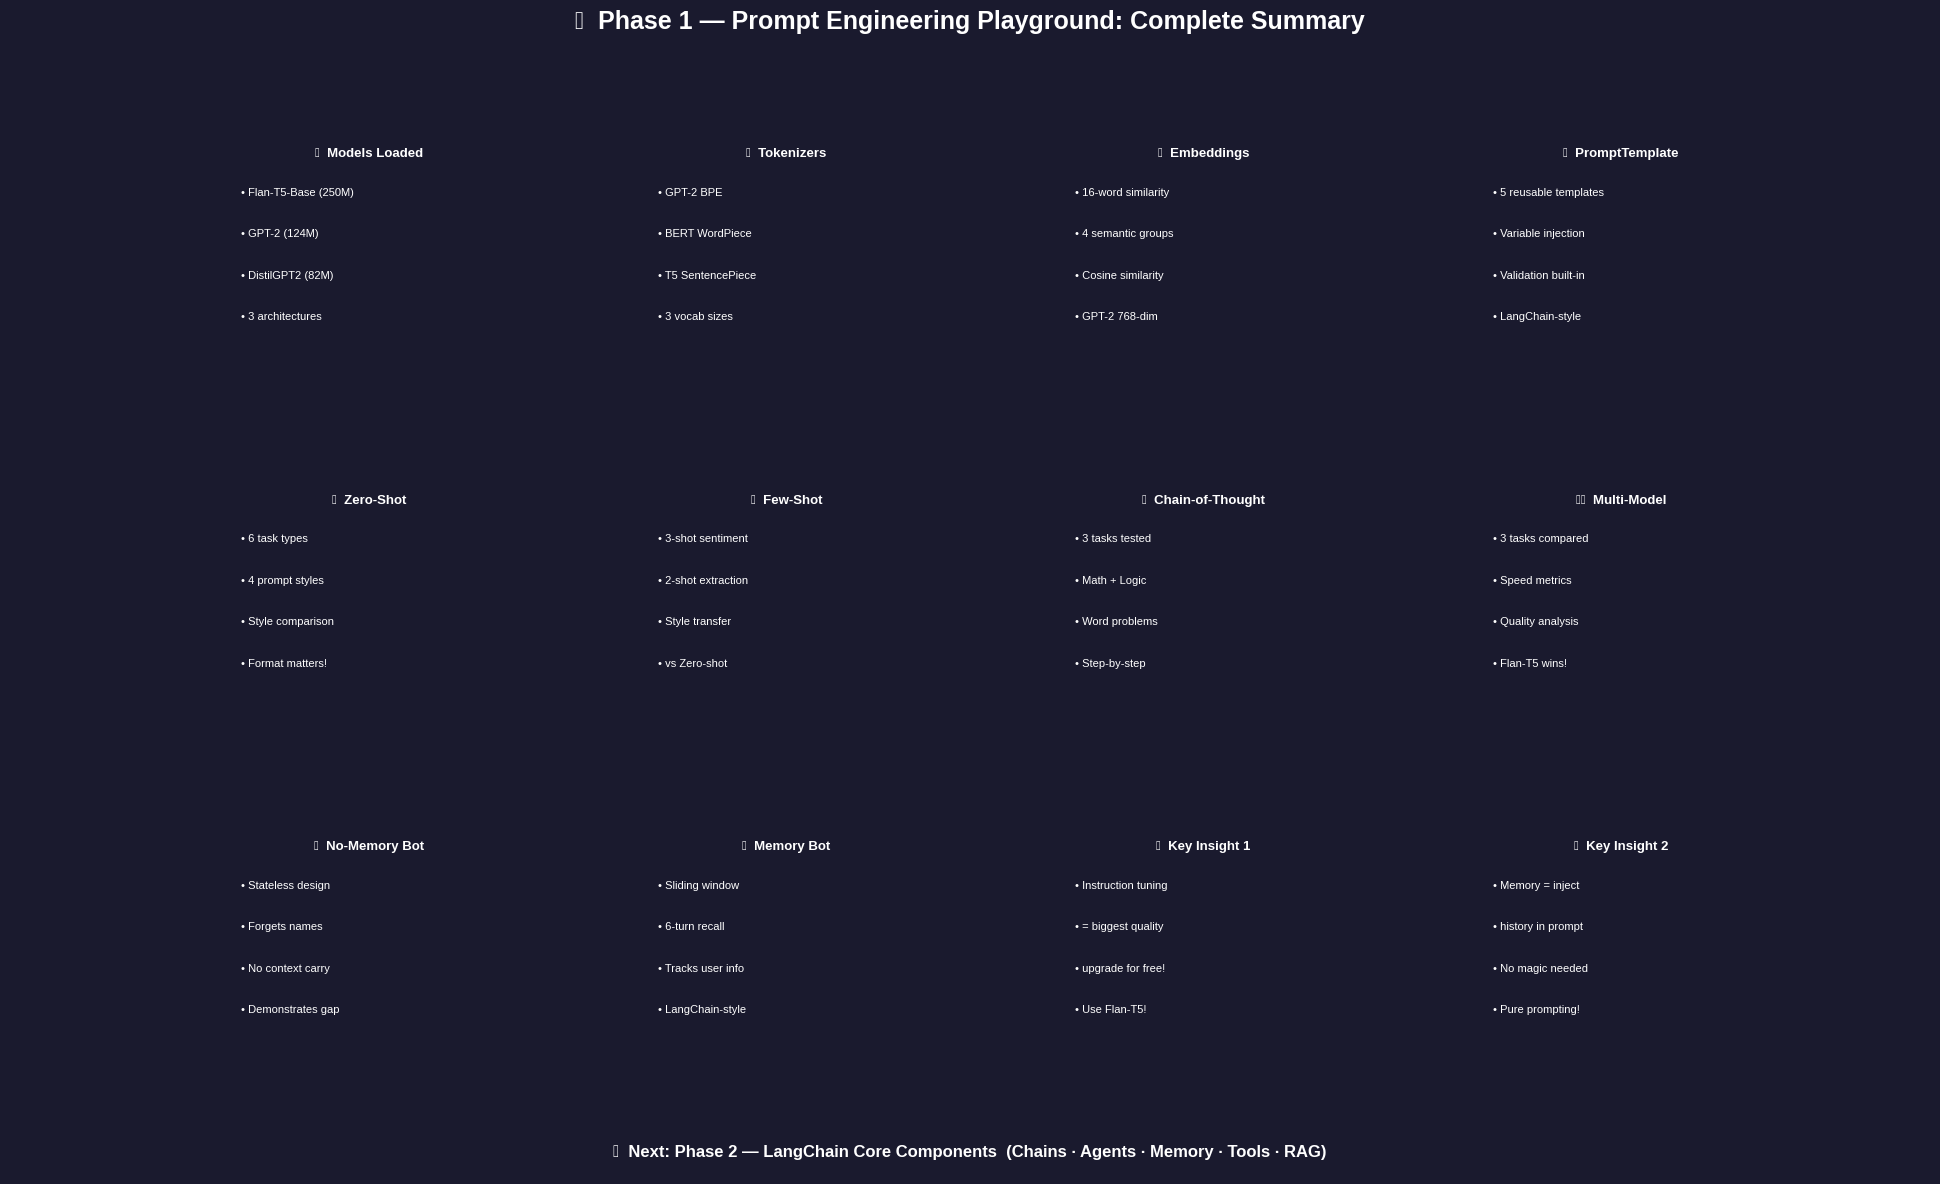


📊 Saved: phase1_summary_dashboard.png


In [28]:
# ─── Phase 1 Summary Dashboard
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("🚀  Phase 1 — Prompt Engineering Playground: Complete Summary",
             fontsize=18, fontweight="bold", color="white", y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# Card helper
def add_card(ax, title, items, color, icon):
    ax.set_facecolor(color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0.5, 0.92, f"{icon}  {title}", ha="center", va="top",
            fontsize=9.5, color="white", fontweight="bold",
            transform=ax.transAxes)
    for i, item in enumerate(items):
        ax.text(0.07, 0.75 - i * 0.18, f"• {item}", ha="left", va="top",
                fontsize=8, color="white", transform=ax.transAxes)

# Card data
cards = [
    ("Models Loaded",     ["Flan-T5-Base (250M)", "GPT-2 (124M)",    "DistilGPT2 (82M)",  "3 architectures"],  "#16213e", "🤖"),
    ("Tokenizers",        ["GPT-2 BPE",            "BERT WordPiece",   "T5 SentencePiece",  "3 vocab sizes"],    "#0f3460", "🔤"),
    ("Embeddings",        ["16-word similarity",   "4 semantic groups","Cosine similarity", "GPT-2 768-dim"],    "#533483", "🔢"),
    ("PromptTemplate",    ["5 reusable templates", "Variable injection","Validation built-in","LangChain-style"],"#2b2d42", "📋"),
    ("Zero-Shot",         ["6 task types",         "4 prompt styles",  "Style comparison",  "Format matters!"],  "#8d1439", "🎯"),
    ("Few-Shot",          ["3-shot sentiment",      "2-shot extraction","Style transfer",    "vs Zero-shot"],     "#e94560", "📸"),
    ("Chain-of-Thought",  ["3 tasks tested",        "Math + Logic",     "Word problems",     "Step-by-step"],     "#0e7c7b", "🧠"),
    ("Multi-Model",       ["3 tasks compared",      "Speed metrics",    "Quality analysis",  "Flan-T5 wins!"],    "#17c3b2", "⚖️"),
    ("No-Memory Bot",     ["Stateless design",      "Forgets names",    "No context carry",  "Demonstrates gap"],"#c77dff", "❌"),
    ("Memory Bot",        ["Sliding window",        "6-turn recall",    "Tracks user info",  "LangChain-style"],  "#7b2d8b", "✅"),
    ("Key Insight 1",     ["Instruction tuning",    "= biggest quality","upgrade for free!", "Use Flan-T5!"],     "#ff6b6b", "💡"),
    ("Key Insight 2",     ["Memory = inject",       "history in prompt","No magic needed",   "Pure prompting!"],  "#ffd166", "💡"),
]

positions = [(i // 4, i % 4) for i in range(12)]
for (row, col), (title, items, color, icon) in zip(positions, cards):
    ax = fig.add_subplot(gs[row, col])
    add_card(ax, title, items, color, icon)

# Bottom banner
ax_banner = fig.add_axes([0.02, 0.01, 0.96, 0.035])
ax_banner.set_facecolor("#e94560")
ax_banner.axis("off")
ax_banner.text(0.5, 0.5,
    "⏭  Next: Phase 2 — LangChain Core Components  (Chains · Agents · Memory · Tools · RAG)",
    ha="center", va="center", fontsize=12, color="white", fontweight="bold")

plt.savefig("phase1_summary_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("\n📊 Saved: phase1_summary_dashboard.png")

In [29]:
# ─── Final Checklist ──────────────────────────────────────────────────────────
checklist = [
    "Installed all libraries and detected CPU/GPU environment",
    "Loaded 3 different HuggingFace models (Flan-T5, GPT-2, DistilGPT2)",
    "Compared tokenization across BPE, WordPiece, SentencePiece",
    "Extracted GPT-2 embeddings and visualized cosine similarity",
    "Built a LangChain-style PromptTemplate class with validation",
    "Implemented and tested 5 reusable prompt templates",
    "Ran zero-shot prompting across 6 different task types",
    "Compared 4 zero-shot prompt styles on the same task",
    "Built a few-shot prompt builder utility",
    "Compared zero-shot vs few-shot with visualizations",
    "Implemented Chain-of-Thought prompting on 3 reasoning tasks",
    "Compared all 3 models on 3 tasks with speed metrics",
    "Built a StatelessChatbot and demonstrated the memory problem",
    "Built a MemoryChatbot with sliding context-window memory",
    "Ran a 6-turn extended memory test session",
    "Generated full visual summary dashboard",
]

print("\n" + "═" * 64)
print("     PHASE 1 PROJECT COMPLETION CHECKLIST")
print("═" * 64)
for i, item in enumerate(checklist, 1):
    print(f"    {i:02d}. {item}")
print("═" * 64)
print(f"    {len(checklist)}/{len(checklist)} tasks completed!")
print(f"    Ready for Phase 2 — LangChain Core Components!")
print("═" * 64)


════════════════════════════════════════════════════════════════
     PHASE 1 PROJECT COMPLETION CHECKLIST
════════════════════════════════════════════════════════════════
    01. Installed all libraries and detected CPU/GPU environment
    02. Loaded 3 different HuggingFace models (Flan-T5, GPT-2, DistilGPT2)
    03. Compared tokenization across BPE, WordPiece, SentencePiece
    04. Extracted GPT-2 embeddings and visualized cosine similarity
    05. Built a LangChain-style PromptTemplate class with validation
    06. Implemented and tested 5 reusable prompt templates
    07. Ran zero-shot prompting across 6 different task types
    08. Compared 4 zero-shot prompt styles on the same task
    09. Built a few-shot prompt builder utility
    10. Compared zero-shot vs few-shot with visualizations
    11. Implemented Chain-of-Thought prompting on 3 reasoning tasks
    12. Compared all 3 models on 3 tasks with speed metrics
    13. Built a StatelessChatbot and demonstrated the memory proble